<a href="https://colab.research.google.com/github/romeromariano03/romeromariano03.github.io/blob/main/retenciones_decreto423_2026_2028.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Impacto fiscal y productivo del cronograma de reducción de retenciones (Decreto 423/2026)
## Modelo de escenarios 2026–2028, con extensión 2029–2030

**Autor:** Mariano Romero | **Fuentes:** BCR/GEA, INDEC, CIARA-CEC, SAGyP, Boletín Oficial, ARCA

**Metodología en una línea:** aritmética bottom-up por complejo y subproducto
(volumen × FOB × alícuota para granos; valor exportado × alícuota para derivados industrializados),
calibrada contra anclas publicadas (BCR, Hacienda) antes de proyectar, con escenarios
de política sobre el cronograma oficial y bandas de precios/producción explícitas.

**Regla del proyecto:** ningún número sin fuente. Todo supuesto, rotulado y con sensibilidad.

| Sección | Contenido | Estado |
|---|---|---|
| 0 | Setup | ✅ |
| 1 | Datos (6 insumos + anclas) | ✅ |
| 2 | Anatomía de la liquidación y DEX agro | ✅ |
| 3 | Núcleo fiscal: calibración, escenarios, costo fiscal | 🔧 sesión 3 |
| 4 | Eje productor: FAS teórico y márgenes | 🔧 sesión 4 |
| 5 | Eje producción: elasticidades y 2da vuelta fiscal | 🔧 sesión 4 |
| 6 | Síntesis y contraste con estimaciones oficiales | 🔧 sesión 5 |
| 7 | Supuestos y limitaciones | 🔧 sesión 5 |

## 0. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
RUTA = '/content/drive/MyDrive/retenciones_2030/'
plt.rcParams.update({'figure.figsize': (12, 4.5), 'axes.spines.top': False,
                     'axes.spines.right': False})
AZUL, ROJO, VERDE, GRIS = '#1a3a5c', '#c0392b', '#2e7d32', '#888888'

Mounted at /content/drive


## 1. Datos
Seis insumos, todos con fuente primaria. Archivos requeridos en `RUTA`:
`liquidacion_ciara_cec_2002_2026.csv` · `alicuotas_dex_2026_2030.csv` ·
`tabla_maestra_v3.csv` · `complejos_exportadores_serie_2002_2025.xlsx`

### 1.1 Liquidación de divisas agro — CIARA-CEC (mensual, USD)

In [3]:
liq = pd.read_csv(RUTA + 'liquidacion_ciara_cec_2002_2026.csv', parse_dates=['fecha'])

# Mayo 2026: US$ 2.677 M (comunicado CIARA-CEC 1/6/26, +7% m/m, -12% i.a.)
# PROVISORIO hasta reemplazar por el próximo xls oficial de CIARA
if liq.fecha.max() < pd.Timestamp('2026-05-01'):
    liq = pd.concat([liq, pd.DataFrame({'fecha': [pd.Timestamp('2026-05-01')],
                                        'liquidacion_usd': [2_677_000_000]})],
                    ignore_index=True)
print(f"{len(liq)} obs | {liq.fecha.min():%Y-%m} a {liq.fecha.max():%Y-%m}")

288 obs | 2002-06 a 2026-05


### 1.2 Cronograma de alícuotas — Decreto 423/2026 (Anexos I-III, Boletín Oficial)

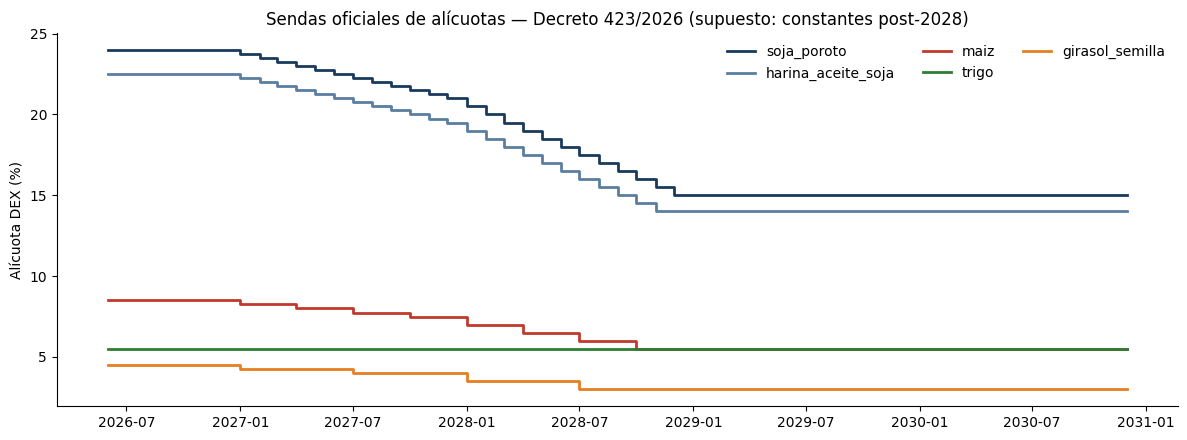

In [4]:
ali = pd.read_csv(RUTA + 'alicuotas_dex_2026_2030.csv')
ali['fecha'] = pd.PeriodIndex(ali.fecha, freq='M').to_timestamp()

fig, ax = plt.subplots()
for col, c in [('soja_poroto', AZUL), ('harina_aceite_soja', '#5a7da0'),
               ('maiz', ROJO), ('trigo', VERDE), ('girasol_semilla', '#e67e22')]:
    ax.plot(ali.fecha, ali[col], label=col, lw=2,
            drawstyle='steps-post', color=c)
ax.set_ylabel('Alícuota DEX (%)'); ax.legend(frameon=False, ncol=3)
ax.set_title('Sendas oficiales de alícuotas — Decreto 423/2026 (supuesto: constantes post-2028)')
plt.tight_layout(); plt.savefig(RUTA + 'fig1_cronograma_alicuotas.png', dpi=200)

### 1.3 Tabla maestra de campañas (balances BCR + estimaciones, con trazabilidad)

In [5]:
tm = pd.read_csv(RUTA + 'tabla_maestra_v3.csv')
print(tm.estado.value_counts().to_string())
assert (tm[tm.estado == 'DATO'].valor.notna()).all(), 'Hay DATOs sin valor'
tm[tm.estado != 'DATO']  # pendientes y no-requeridos, a la vista siempre

estado
DATO            62
NO_REQUERIDO     5
PENDIENTE        2


,complejo,variable,campania,valor,unidad,fuente,estado
20,soja,expo_harina,2025/26,NaN,Mt,se modela por VALOR (INDEC subproductos + alíc...,NO_REQUERIDO
21,soja,expo_aceite,2025/26,NaN,Mt,se modela por VALOR (INDEC subproductos + alíc...,NO_REQUERIDO
22,soja,expo_biodiesel,2025/26,NaN,Mt,se modela por VALOR (INDEC subproductos + alíc...,NO_REQUERIDO
37,cebada,produccion,2025/26,NaN,Mt,Balance BCR cebada — conseguir,PENDIENTE
41,girasol,expo_aceite,2025/26,NaN,Mt,se modela por VALOR (INDEC subproductos + alíc...,NO_REQUERIDO
42,girasol,expo_pellets,2025/26,NaN,Mt,se modela por VALOR (INDEC subproductos + alíc...,NO_REQUERIDO
44,sorgo,exportaciones,2025/26,NaN,Mt,Balance/DJVE — conseguir,PENDIENTE


### 1.4 Exportaciones por complejo — INDEC 2002-2025 (valores, USD)

In [6]:
# %% ─── CELDA 1.4: Exportaciones por complejo INDEC (corregida) ───
raw = pd.read_excel(RUTA + 'complejos_exportadores_serie_2002_2025.xlsx', header=None)
anios = list(range(2002, 2026))
filas = {'Complejo soja': 'soja', 'Harinas y pellets de soja': 'soja_harina',
         'Aceite de soja': 'soja_aceite', 'Porotos de soja': 'soja_poroto',
         'Biodiésel': 'soja_biodiesel', 'Complejo maicero': 'maiz',
         'Complejo triguero': 'trigo', 'Complejo cebada': 'cebada',
         'Complejo girasol': 'girasol', 'Total de exportaciones': 'total'}
recs = {}
for patron, nombre in filas.items():
    fila = raw[raw[0].astype(str).str.strip() == patron]
    if len(fila):
        recs[nombre] = pd.to_numeric(fila.iloc[0, 1:25], errors='coerce').values
indec = pd.DataFrame(recs, index=anios)

faltantes = [k for k in filas.values() if k not in recs]
if faltantes: print('⚠️ Filas no encontradas:', faltantes)
print(indec.tail(3).round(0).to_string())
print('\nNaN por columna:', indec.isna().sum().to_dict())

         soja  soja_harina  soja_aceite  soja_poroto  soja_biodiesel    maiz   trigo  cebada  girasol    total
2023  13980.0       8029.0       4179.0       1038.0           341.0  6427.0  1446.0  1327.0   1420.0  66956.0
2024  19628.0      10561.0       6333.0       2014.0           388.0  7264.0  2764.0  1212.0   1453.0  79703.0
2025  21442.0       8566.0       7220.0       4916.0           322.0  6660.0  3649.0  1081.0   2175.0  87111.0

NaN por columna: {'soja': 0, 'soja_harina': 0, 'soja_aceite': 0, 'soja_poroto': 0, 'soja_biodiesel': 10, 'maiz': 0, 'trigo': 0, 'cebada': 0, 'girasol': 0, 'total': 0}


### 1.5 FOB oficiales — datos.gob.ar (SAGyP/DINEM, diario → promedio mensual)

In [7]:
# %% ─── CELDA 1.5: FOB oficiales DINEM (curva forward por posición) ───
fob_long = pd.read_csv(RUTA + 'fob_oficiales_dinem_20260609.csv')

# Expandir cada ventana de embarque a meses individuales para hacer lookup directo
def expandir(r):
    if r.embarque == '0-00 a 0-00':              # precio único vigente
        meses = pd.date_range('2026-06-01', '2027-05-01', freq='MS')
    else:
        d, h = r.embarque.split(' a ')
        meses = pd.date_range(d + '-01', h + '-01', freq='MS')
    return pd.DataFrame({'posicion': r.posicion, 'mes': meses, 'fob_usd_t': r.fob_usd_t})

# Para posiciones con múltiples comercializaciones (cebada, sorgo, girasol semilla),
# nos quedamos con "granel ≤15% embolsado": el estándar para el cálculo FOB de DEX
es_granel = fob_long.comercializacion.str.contains('granel', case=False, na=False)
sin_com   = fob_long.posicion.isin(['aceite_soja','aceite_girasol','harina_soja'])
fob_long  = fob_long[es_granel | sin_com].copy()

fob_curva = pd.concat([expandir(r) for _, r in fob_long.iterrows()], ignore_index=True)
fob = fob_curva.pivot_table(index='mes', columns='posicion', values='fob_usd_t').reset_index()
fob = fob.rename(columns={'mes':'fecha'})

fob.to_csv(RUTA + 'fob_oficiales_mensual.csv', index=False)
print(f"Curva FOB: {fob.fecha.min():%Y-%m} a {fob.fecha.max():%Y-%m} ({len(fob)} meses)")
print(fob.round(0).to_string(index=False))

Curva FOB: 2026-06 a 2027-05 (12 meses)
     fecha  aceite_girasol  aceite_soja  cebada_cervecera  cebada_forrajera  girasol_semilla  harina_soja  maiz  soja_poroto  sorgo  trigo
2026-06-01          1302.0       1174.0             262.0             235.0            482.0        326.0 197.0        410.0  232.0  237.0
2026-07-01          1302.0       1170.0             262.0             235.0            482.0        326.0 197.0        413.0  232.0  239.0
2026-08-01          1302.0       1170.0             262.0             235.0            482.0        328.0 199.0        418.0  232.0  238.0
2026-09-01          1302.0       1146.0             262.0             235.0            482.0        334.0 200.0        427.0  232.0  238.0
2026-10-01          1290.0       1161.0             262.0             235.0            482.0        334.0 205.0        447.0  232.0  238.0
2026-11-01          1283.0       1146.0             262.0             235.0            482.0        334.0 205.0        447.0  

### 1.6 Parámetros GEA — márgenes zona núcleo 2026/27 (GEA N°970, 20/5/26)

In [9]:
GEA = {  # u$s/ha salvo indicación; explotación 150 ha a 150 km de Rosario
  'soja_1ra': dict(precio_qq=34.2, rinde_qq=40, margen_propio=445, margen_alq=5,   inversion=736),
  'maiz':     dict(precio_qq=19.7, rinde_qq=100, margen_propio=437, margen_alq=4,  inversion=1343),
  'trigo':    dict(precio_qq=23.1, rinde_qq=40, margen_propio=94,  margen_alq=-103, inversion=772),
  'trigo_soja2da': dict(margen_propio=519, margen_alq=50, inversion=1377),
}
ALQUILER_QQ_HA = 18  # quintales de soja por hectárea

### 1.7 Anclas de calibración — el modelo debe reproducirlas antes de proyectar

In [10]:
ANCLAS = {
  'liq_2026_musd':        36_111,   # BCR may-26
  'dex_agro_2026_musd':    4_650,   # BCR mar-26 (6 complejos)
  'dex_soja_2026_musd':    3_420,   # BCR mar-26
  'liq_abr_dic_2026': dict(soja=16_500, maiz=7_500, girasol=2_400, trigo=2_200,
                           cebada=500, sorgo=300, otros=600),  # BCR 10/4/26
  'caputo_costo_fiscal': {2026: 32, 2027: 415, 2028: 1_224},   # MUSD, Hacienda jun-26
  'bcr_costo_trigo_cebada_2526_musd': 29.5,                    # BCR 22/5/26
}
TOLERANCIA_CALIBRACION = 0.05

## 2. Anatomía de la liquidación y el DEX agro
La serie 2002–2026 con los quiebres de política marcados, la estacionalidad
(ponderador intra-anual del módulo fiscal) y el contexto del Decreto 423.

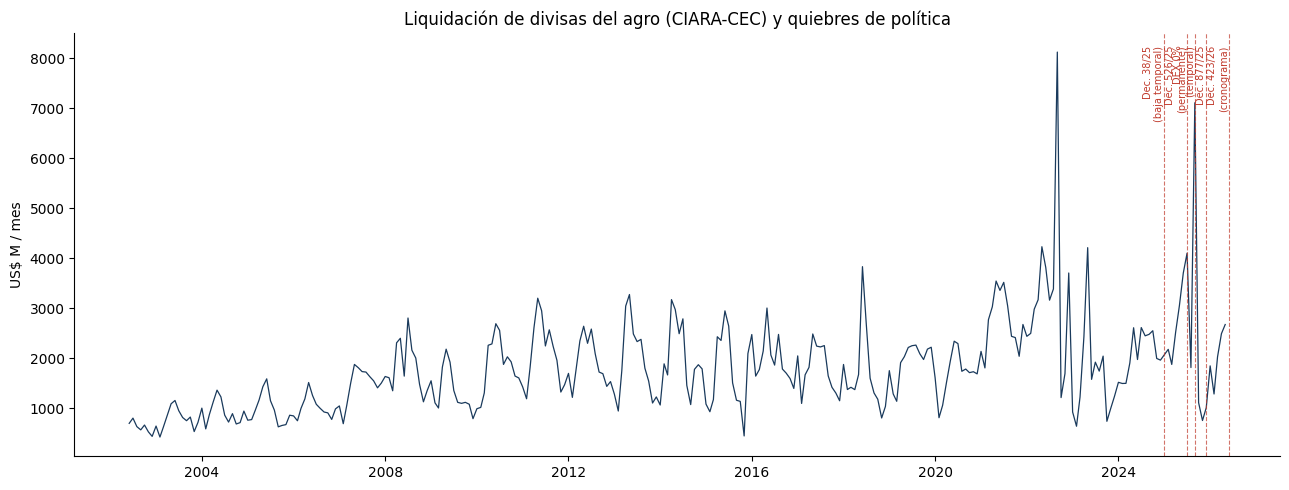

In [11]:
QUIEBRES = {
  '2025-01': 'Dec. 38/25\n(baja temporal)', '2025-07': 'Dec. 526/25\n(permanente)',
  '2025-09': 'DEX 0%\n(temporal)', '2025-12': 'Dec. 877/25',
  '2026-06': 'Dec. 423/26\n(cronograma)',
}
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(liq.fecha, liq.liquidacion_usd / 1e6, lw=0.9, color=AZUL)
for f, txt in QUIEBRES.items():
    x = pd.Timestamp(f)
    ax.axvline(x, color=ROJO, lw=0.8, ls='--', alpha=0.7)
    ax.text(x, ax.get_ylim()[1]*0.97, txt, rotation=90, fontsize=7,
            va='top', ha='right', color=ROJO)
ax.set_ylabel('US$ M / mes')
ax.set_title('Liquidación de divisas del agro (CIARA-CEC) y quiebres de política')
plt.tight_layout(); plt.savefig(RUTA + 'fig2_serie_quiebres.png', dpi=200)

In [12]:
# Estacionalidad: participación promedio de cada mes en el año (excl. años distorsionados)
liq['anio'], liq['mes'] = liq.fecha.dt.year, liq.fecha.dt.month
EXCLUIR = [2022, 2023, 2025]   # dólar soja / sequía / DEX 0%: justificar en sección 7
base = liq[(liq.anio >= 2010) & (~liq.anio.isin(EXCLUIR)) & (liq.anio < 2026)]
w = base.groupby('mes').liquidacion_usd.mean()
PESO_MENSUAL = (w / w.sum()).rename('peso')
print((PESO_MENSUAL * 100).round(1).to_string())
# -> ponderador para promediar alícuotas dentro de cada año calendario

mes
1      6.9
2      5.5
3      6.8
4      9.7
5     11.2
6     11.1
7     10.7
8      9.1
9      7.7
10     7.6
11     6.4
12     7.2


In [13]:
liq.to_parquet(RUTA + 'cache_liq.parquet')
ali.to_parquet(RUTA + 'cache_ali.parquet')
tm.to_parquet(RUTA + 'cache_tm.parquet')
indec.to_parquet(RUTA + 'cache_indec.parquet')
fob.to_parquet(RUTA + 'cache_fob.parquet')
PESO_MENSUAL.to_csv(RUTA + 'cache_peso_mensual.csv')
print('Cache guardado')

Cache guardado


## 3. Núcleo fiscal — 🔧 SESIÓN 3
**3.1 Calibración 2026.** DEX por complejo = base × alícuota vigente ponderada por
`PESO_MENSUAL`. Base: valor (INDEC/liquidación BCR) para soja y girasol; volumen × FOB
para trigo, cebada, maíz, sorgo. Test: reproducir `ANCLAS` con error ≤ 5%.
**3.2 Escenarios de alícuotas.** (A) congelamiento jun-26, (B) cronograma oficial,
(C) eliminación acelerada a 0% en dic-28.
**3.3 Costo fiscal.** B y C vs A, por año y complejo, banda de precios ±10/15%,
contraste contra `caputo_costo_fiscal` y réplica del ejercicio trigo/cebada de BCR.

In [ ]:
# 3.1 — esqueleto (se construye en la sesión 3, con la calibración como gate)
def dex_complejo_valor(valor_expo_musd, alicuota_pond):
    return valor_expo_musd * alicuota_pond / 100

def dex_complejo_volumen(mt, fob_usd_t, alicuota_pond):
    return mt * fob_usd_t * alicuota_pond / 100 / 1000  # -> MUSD

def alicuota_ponderada(serie_alicuotas_12m, pesos=PESO_MENSUAL):
    return float((serie_alicuotas_12m.values * pesos.values).sum())

## 4. Eje productor — 🔧 SESIÓN 4
FAS teórico = FOB × (1 − alícuota) − gastos fobbing, por cultivo y escenario;
traducción a margen/ha con parámetros `GEA`; brecha precio internacional/percibido.
Réplica del ejercicio de sensibilidad del Informativo BCR 22/5 y extensión a soja/maíz.

## 5. Eje producción — 🔧 SESIÓN 4
Respuesta de oferta: elasticidad precio de la superficie/producción (sensibilidad
0,2 / 0,3 / 0,4, con cita de literatura) aplicada a la mejora del precio percibido
por escenario → Δ producción → segunda vuelta sobre recaudación (compensación
parcial del costo fiscal, à la BCR con su escenario de 20 Mt de trigo).

## 6. Síntesis — 🔧 SESIÓN 5
Matriz política × fundamentos; costo fiscal acumulado 2026-2028; contraste con
Caputo (¿qué supuestos sostienen 32/415/1.224?); extensión 2029-2030 rotulada.

## 7. Supuestos y limitaciones — 🔧 SESIÓN 5
- Liquidación como proxy de base imponible (timing DJVE/embarque/liquidación)
- Márgenes GEA = zona núcleo, no promedio nacional
- Años excluidos del ponderador estacional y justificación
- Alícuotas constantes post-dic-2028 (el decreto declara intención de continuar bajando)
- Discrepancias de fuentes rotuladas (trigo 27,7 vs 29,5; girasol 6,6 vs 7,3)
- Elasticidades de literatura, no estimadas en este trabajo